In [40]:
import gymnasium as gym
import ale_py
from PIL import Image

from IPython.display import display

import numpy as np
from collections import deque
import random
from random import sample
import torch
import tensorflow as tf
import matplotlib.pyplot as plt

gym.register_envs(ale_py)

env = gym.make("ALE/Pong-v5", obs_type="grayscale",render_mode='rgb_array')


{'lives': 0, 'episode_frame_number': 0, 'frame_number': 0}


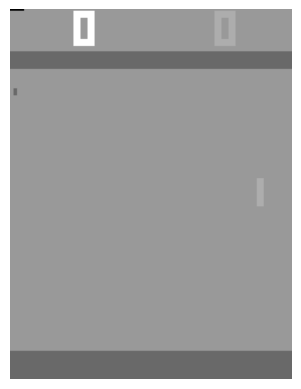

In [41]:
captured = env.reset()

pixels = captured[0]
info = captured[1]
print(info)

plt.imshow(pixels, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
captured = env.step(3)
pixels, reward, terminated, truncated, info = captured

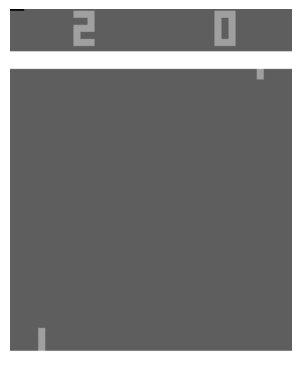

steps: 100, action: 2,  reward: -2.0, done: False, info: {'lives': 0, 'episode_frame_number': 400, 'frame_number': 30988}


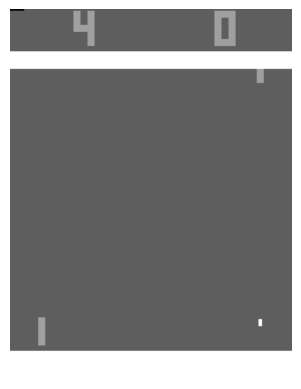

steps: 200, action: 3,  reward: -4.0, done: False, info: {'lives': 0, 'episode_frame_number': 800, 'frame_number': 31388}


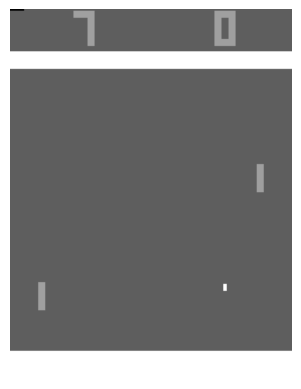

steps: 300, action: 0,  reward: -7.0, done: False, info: {'lives': 0, 'episode_frame_number': 1200, 'frame_number': 31788}


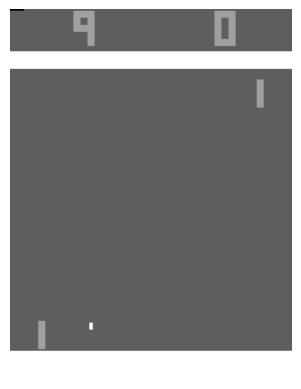

steps: 400, action: 2,  reward: -9.0, done: False, info: {'lives': 0, 'episode_frame_number': 1600, 'frame_number': 32188}


In [52]:
actions = [0,2,3]

start_state, info = env.reset()
fire = 1
done = False
start = True
total_reward = 0
total_steps = 0

while not done:
    if start:
        action = 1
        start = False
    else:
        action = random.choice(actions)
    
    pixels, reward, done, truncated, info = env.step(action)
    
    total_reward += reward
    
    if(total_reward <= -10): done = True
    total_steps += 1
    
    if(total_steps % 100 == 0):
        img = Image.fromarray(pixels)
        img.save(f'Pong/images/img_{total_steps}.png')
        plt.imshow(pixels, cmap='gray')
        plt.axis('off')
        plt.show()
    
        print(f'steps: {total_steps}, action: {action},  reward: {total_reward}, done: {done}, info: {info}')